In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("הכל עובד מצוין!")

הכל עובד מצוין!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("הכל עובד מצוין!")


הכל עובד מצוין!


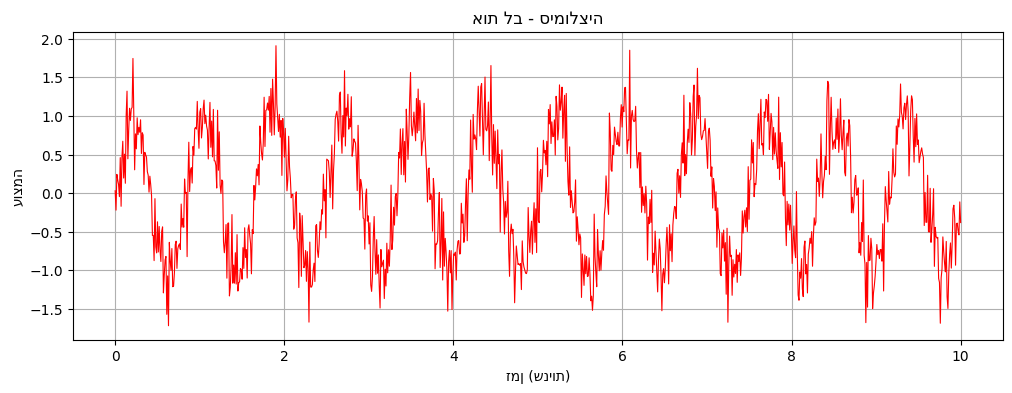

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# יצירת אות לב מדומה
זמן = np.linspace(0, 10, 1000)
אות = np.sin(2 * np.pi * 1.2 * זמן) + 0.3 * np.random.randn(1000)

# הצגת הגרף
plt.figure(figsize=(12, 4))
plt.plot(זמן, אות, color='red', linewidth=0.8)
plt.title('אות לב - סימולציה')
plt.xlabel('זמן (שניות)')
plt.ylabel('עוצמה')
plt.grid(True)
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# טעינת הדאטא
df = pd.read_csv(r'C:\Users\alon4\Desktop\ECG-project\mitbih_train.csv', header=None)

# בדיקה ראשונה
print("גודל הדאטא:", df.shape)
print("5 שורות ראשונות:")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\alon4\\Desktop\\ECG-project\\mitbih_train.csv'

In [5]:
import os
print(os.path.expanduser("~"))


C:\Users\alon4


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\alon4\Desktop\ecg-project\mitbih_train.csv', header=None)

print("גודל הדאטא:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\alon4\\Desktop\\ecg-project\\mitbih_train.csv'

In [7]:
import os

for root, dirs, files in os.walk(r'C:\Users\alon4'):
    for file in files:
        if 'mitbih' in file:
            print(os.path.join(root, file))
            

C:\Users\alon4\OneDrive\Desktop\ecg-project\mitbih_test.csv
C:\Users\alon4\OneDrive\Desktop\ecg-project\mitbih_train.csv


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\alon4\OneDrive\Desktop\ecg-project\mitbih_train.csv', header=None)

print("גודל הדאטא:", df.shape)
df.head()

גודל הדאטא: (87554, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


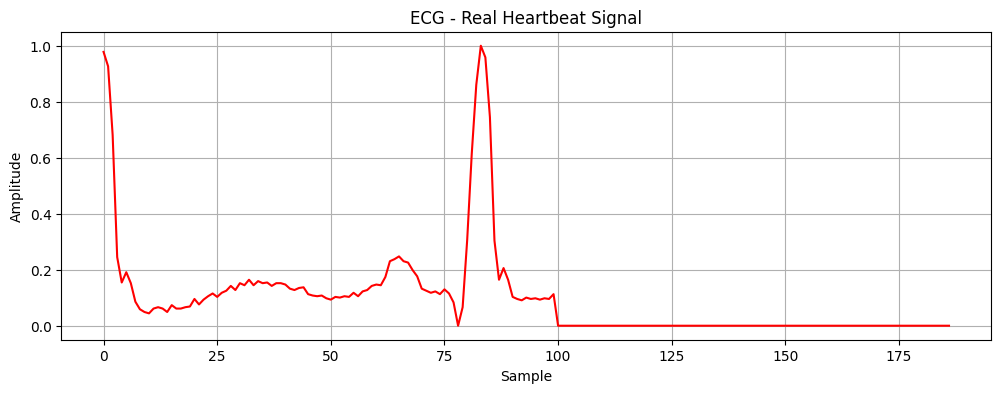

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df.iloc[0, :187], color='red', linewidth=1.5)
plt.title('ECG - Real Heartbeat Signal')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

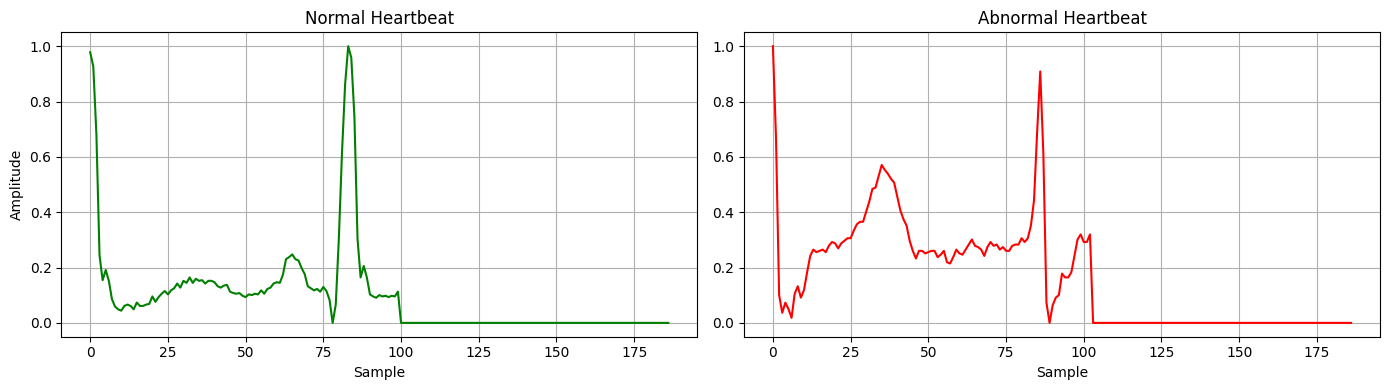

In [10]:
# פעימה תקינה vs חריגה
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# תקינה - סוג 0
normal = df[df[187] == 0].iloc[0, :187]
axes[0].plot(normal, color='green', linewidth=1.5)
axes[0].set_title('Normal Heartbeat')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)

# חריגה - סוג 1
abnormal = df[df[187] == 1].iloc[0, :187]
axes[1].plot(abnormal, color='red', linewidth=1.5)
axes[1].set_title('Abnormal Heartbeat')
axes[1].set_xlabel('Sample')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# הכנת הדאטא
X = df.iloc[:, :187].values  # האות עצמו
y = df.iloc[:, 187].values   # התווית - תקין או חריג

# חלוקה ל-80% אימון ו-20% בדיקה
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("גודל סט אימון:", X_train.shape)
print("גודל סט בדיקה:", X_test.shape)
print("מתחיל לאמן את המודל... זה ייקח כדקה")

# אימון המודל
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# בדיקת דיוק
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nדיוק המודל: {accuracy * 100:.2f}%")

גודל סט אימון: (70043, 187)
גודל סט בדיקה: (17511, 187)
מתחיל לאמן את המודל... זה ייקח כדקה

דיוק המודל: 97.53%


In [12]:
print("=" * 50)
print("ECG Heartbeat Classification Project")
print("=" * 50)
print(f"סה״כ דאטא: {len(df):,} פעימות לב")
print(f"סט אימון: {len(X_train):,} פעימות")
print(f"סט בדיקה: {len(X_test):,} פעימות")
print(f"דיוק המודל: {accuracy * 100:.2f}%")
print("=" * 50)
print("מודל: Random Forest - 100 עצי החלטה")
print("דאטא: MIT-BIH Arrhythmia Database")
print("=" * 50)

ECG Heartbeat Classification Project
סה״כ דאטא: 87,554 פעימות לב
סט אימון: 70,043 פעימות
סט בדיקה: 17,511 פעימות
דיוק המודל: 97.53%
מודל: Random Forest - 100 עצי החלטה
דאטא: MIT-BIH Arrhythmia Database


In [13]:
# שמירת הנוטבוק כקובץ
import json

notebook_content = {
    "cells": [],
    "metadata": {
        "kernelspec": {
            "display_name": "Python 3",
            "language": "python",
            "name": "python3"
        }
    },
    "nbformat": 4,
    "nbformat_minor": 4
}

print("עכשיו שמור את הנוטבוק:")
print("לחץ File ← Save Notebook")
print("שם הקובץ: ecg_classifier.ipynb")

עכשיו שמור את הנוטבוק:
לחץ File ← Save Notebook
שם הקובץ: ecg_classifier.ipynb
